#### **CORD's ground_truth** field is a raw JSON string. You must parse it and construct a flat text target from the menu array

In [1]:
import json
from collections import defaultdict
from PIL import Image

def extract_cord_crops(image: Image.Image, ground_truth_str: str) -> list:
    """
    Extract line-level crops from a CORD receipt image.

    Bounding boxes are in valid_line[].words[].quad, NOT in gt_parse.menu.
    Each group_id in valid_line = one logical receipt line.
    We group words by group_id, merge their quads into one bbox, crop it,
    and use the joined word texts as the OCR target.
    Only menu.* categories are kept (skip total, tax, header lines).

    Returns list of (cropped_PIL_image, text) pairs.
    """
    try:
        data = json.loads(ground_truth_str)
    except (json.JSONDecodeError, AttributeError):
        return []

    valid_lines = data.get("valid_line", [])
    if not valid_lines:
        return []

    # Group lines by group_id
    groups = defaultdict(list)
    for line in valid_lines:
        groups[line["group_id"]].append(line)

    w, h = image.size
    crops = []

    for gid, lines in groups.items():
        # Only keep menu lines (skip total, sub_total, etc.)
        if not any(l.get("category", "").startswith("menu.") for l in lines):
            continue

        all_words, all_xs, all_ys = [], [], []
        for line in lines:
            for word in line.get("words", []):
                text = word.get("text", "").strip()
                if text:
                    all_words.append(text)
                q = word.get("quad", {})
                if q:
                    all_xs += [q.get("x1",0), q.get("x2",0), q.get("x3",0), q.get("x4",0)]
                    all_ys += [q.get("y1",0), q.get("y2",0), q.get("y3",0), q.get("y4",0)]

        if not all_words or not all_xs:
            continue

        text = " ".join(all_words)
        x1, y1 = max(0, min(all_xs)), max(0, min(all_ys))
        x2, y2 = min(w, max(all_xs)), min(h, max(all_ys))
        if x2 <= x1 or y2 <= y1:
            continue

        crops.append((image.crop((x1, y1, x2, y2)), text))

    return crops

### **SROIE** Text Reconstruction
#### SROIE has bboxes per word. Group words by Y-coordinate (within 15px = same line), merge bounding boxes per line, crop each line region

In [2]:
def extract_sroie_crops(image: Image.Image, words: list, bboxes: list) -> list:
    """
    Group SROIE words into lines by Y-coordinate proximity.
    Each line bbox is cropped and paired with its joined text.
    Returns list of (cropped_PIL_image, text) pairs.
    """
    if not words or not bboxes:
        return []

    # Sort by top-Y of each word bbox
    items = sorted(zip(words, bboxes), key=lambda x: x[1][1])

    # Group into lines: words within 15px vertically = same line
    lines = []
    current_words, current_boxes = [items[0][0]], [items[0][1]]
    for word, box in items[1:]:
        if abs(box[1] - current_boxes[-1][1]) <= 15:
            current_words.append(word)
            current_boxes.append(box)
        else:
            lines.append((current_words, current_boxes))
            current_words, current_boxes = [word], [box]
    lines.append((current_words, current_boxes))

    w, h = image.size
    crops = []
    for line_words, line_boxes in lines:
        text = " ".join(line_words).strip()
        if not text:
            continue
        x1 = max(0, min(b[0] for b in line_boxes))
        y1 = max(0, min(b[1] for b in line_boxes))
        x2 = min(w, max(b[2] for b in line_boxes))
        y2 = min(h, max(b[3] for b in line_boxes))
        if x2 <= x1 or y2 <= y1:
            continue
        crops.append((image.crop((x1, y1, x2, y2)), text))
    return crops

### Combined Dataset Builder
OOM fix: Images encoded to PNG bytes immediately — no PIL accumulation in RAM.
Line crops: Each receipt yields multiple (crop, text) pairs instead of one (full_image, all_text).
SROIE 2x weighting: SROIE train concatenated twice — gives more weight to English receipt text vs CORD's Indonesian menus.
New dataset path: Since this is a rebuilt dataset, save to a new path to avoid loading the old full-image version.

In [3]:
import io
import json
from pathlib import Path
from datasets import load_dataset, Dataset, DatasetDict
from PIL import Image

# New path — line-crop dataset is incompatible with old full-image dataset
SAVE_PATH = Path("/kaggle/working/smart_stock_dataset_v2")

def pil_to_bytes(img: Image.Image) -> bytes:
    buf = io.BytesIO()
    img.convert("RGB").save(buf, format="PNG")
    return buf.getvalue()

def iter_to_dataset(iterator) -> Dataset:
    """
    Convert an iterator of (PIL Image, text) tuples into a Dataset.
    Encodes each image to bytes immediately — never accumulates PIL objects in RAM.
    """
    img_bytes, texts = [], []
    for img, text in iterator:
        img_bytes.append(pil_to_bytes(img))
        texts.append(text)
    return Dataset.from_dict({"image_bytes": img_bytes, "text": texts})

def build_and_save_dataset():
    """
    Build line-crop CORD + SROIE dataset and save to disk.
    On subsequent runs, loads directly from disk — no reprocessing.
    """
    if SAVE_PATH.exists():
        print(f"Dataset found at {SAVE_PATH} — loading from disk...")
        return DatasetDict.load_from_disk(str(SAVE_PATH))

    print("Building line-crop dataset from scratch...")

    # --- CORD — line crops via bounding boxes ---
    print("Loading CORD...")
    cord = load_dataset("naver-clova-ix/cord-v2")

    def cord_iter(split):
        for ex in cord[split]:
            for crop, text in extract_cord_crops(ex["image"], ex["ground_truth"]):
                yield crop, text

    cord_train      = iter_to_dataset(cord_iter("train"))
    cord_validation = iter_to_dataset(cord_iter("validation"))
    cord_test       = iter_to_dataset(cord_iter("test"))
    print(f"  CORD train: {len(cord_train)} | val: {len(cord_validation)} | test: {len(cord_test)}")
    del cord

    # --- SROIE — line crops via word bbox grouping ---
    print("Loading SROIE...")
    sroie = load_dataset("sizhkhy/SROIE")

    def sroie_iter(split):
        for ex in sroie[split]:
            for crop, text in extract_sroie_crops(ex["images"], ex["words"], ex["bboxes"]):
                yield crop, text

    sroie_train = iter_to_dataset(sroie_iter("train"))
    sroie_test  = iter_to_dataset(sroie_iter("test"))
    print(f"  SROIE train: {len(sroie_train)} | test: {len(sroie_test)}")
    del sroie

    # --- Combine ---
    # SROIE train duplicated for 2x weight (more English receipt signal)
    # validation = CORD only (SROIE has no val split)
    from datasets import concatenate_datasets
    dataset_dict = DatasetDict({
        "train":      concatenate_datasets([cord_train, sroie_train, sroie_train]),
        "validation": cord_validation,
        "test":       concatenate_datasets([cord_test, sroie_test]),
    })

    SAVE_PATH.mkdir(parents=True, exist_ok=True)
    dataset_dict.save_to_disk(str(SAVE_PATH))

    print(f"\n✅ Saved to {SAVE_PATH}")
    print(f"   Train:      {len(dataset_dict['train'])}")
    print(f"   Validation: {len(dataset_dict['validation'])}")
    print(f"   Test:       {len(dataset_dict['test'])}")
    return dataset_dict

combined_dataset = build_and_save_dataset()

Building line-crop dataset from scratch...
Loading CORD...


README.md:   0%|          | 0.00/27.0 [00:00<?, ?B/s]

dataset_infos.json: 0.00B [00:00, ?B/s]

data/train-00000-of-00004-b4aaeceff1d90e(…):   0%|          | 0.00/490M [00:00<?, ?B/s]

data/train-00001-of-00004-7dbbe248962764(…):   0%|          | 0.00/441M [00:00<?, ?B/s]

...

  SROIE train: 14476 | test: 8050


Saving the dataset (0/1 shards):   0%|          | 0/31057 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/221 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/8301 [00:00<?, ? examples/s]


✅ Saved to /kaggle/working/smart_stock_dataset_v2
   Train:      31057
   Validation: 221
   Test:       8301


#### Expected sizes (line crops):

Train: ~24,000+ examples (CORD ~6k + SROIE ~9k × 2)
Validation: ~800 examples (CORD val crops)
Test: ~6,000 examples (CORD + SROIE test crops)

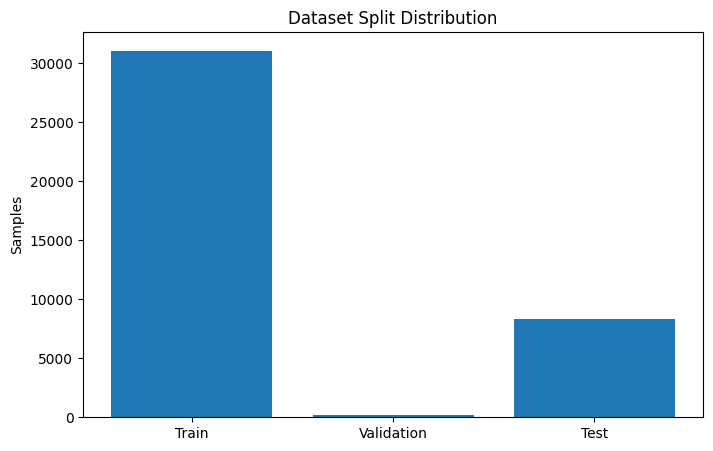

In [4]:
import matplotlib.pyplot as plt

train_size = len(combined_dataset["train"])
val_size   = len(combined_dataset["validation"])
test_size  = len(combined_dataset["test"])

plt.figure(figsize=(8,5))

plt.bar(
    ["Train","Validation","Test"],
    [train_size,val_size,test_size]
)

plt.title("Dataset Split Distribution")
plt.ylabel("Samples")

plt.show()

#### **Augmentation** 
Apply augmentation only to training images, inline during the preprocess_trocr step. The augmentation simulates real-world receipt degradation.

In [5]:
import albumentations as A
import cv2
import numpy as np
from PIL import Image, ImageOps

receipt_augmentation = A.Compose([
    A.RandomBrightnessContrast(brightness_limit=(-0.3, 0.1), p=0.5),  # Thermal fade
    A.GaussNoise(p=0.4),                                               # Scanner noise
    A.Rotate(limit=5, border_mode=cv2.BORDER_REPLICATE, p=0.5),        # Crumple tilt
    A.Perspective(scale=(0.02, 0.05), p=0.3),                          # Photo angle
    A.MotionBlur(blur_limit=3, p=0.2),                                 # Shaky photo
    A.ImageCompression(p=0.4),                                         # JPEG artifact
])

def apply_augmentation(pil_image: Image.Image) -> Image.Image:
    """Pad tiny line crops to min 32px height, then augment."""
    pil_image = pil_image.convert("RGB")
    if pil_image.height < 32:
        pad = 32 - pil_image.height
        pil_image = ImageOps.expand(pil_image, border=(0, pad//2, 0, pad - pad//2), fill=255)
    img_np = np.array(pil_image)
    augmented = receipt_augmentation(image=img_np)["image"]
    return Image.fromarray(augmented)

### Preprocessing Function

In [6]:
import io
import torch
from torch.utils.data import Dataset as TorchDataset
from transformers import TrOCRProcessor

processor = TrOCRProcessor.from_pretrained("microsoft/trocr-base-printed")

def preprocess_trocr(example, augment: bool = False):
    """
    Preprocess a single (image_bytes, text) example.
    Called per-item at access time — no upfront caching.

    Returns dict with 'pixel_values' (tensor) and 'labels' (tensor).
    """
    image = Image.open(io.BytesIO(example["image_bytes"])).convert("RGB")

    if augment:
        image = apply_augmentation(image)

    pixel_values = processor(images=image, return_tensors="pt").pixel_values

    labels = processor.tokenizer(
        example["text"],
        padding="max_length",
        max_length=128,
        truncation=True,
    ).input_ids

    labels = [
        t if t != processor.tokenizer.pad_token_id else -100
        for t in labels
    ]

    return {
        "pixel_values": pixel_values.squeeze(),
        "labels": torch.tensor(labels, dtype=torch.long),
    }


class TrOCRDataset(TorchDataset):
    """
    On-the-fly preprocessing — processes each example at access time.
    Replaces .map() which caused either:
      - OOM (keep_in_memory=True on 31k examples)
      - OSError Errno 28 (cache_file_name on full disk)
    Zero disk usage, zero RAM accumulation, full dataset used.
    Compatible with Seq2SeqTrainer — accepts any PyTorch Dataset.
    """
    def __init__(self, hf_dataset, augment: bool = False):
        self.data    = hf_dataset
        self.augment = augment

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return preprocess_trocr(self.data[idx], augment=self.augment)


train_dataset = TrOCRDataset(combined_dataset["train"],      augment=True)
val_dataset   = TrOCRDataset(combined_dataset["validation"], augment=False)
test_dataset  = TrOCRDataset(combined_dataset["test"],       augment=False)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

preprocessor_config.json:   0%|          | 0.00/224 [00:00<?, ?B/s]

The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

Train: 31057 | Val: 221 | Test: 8301


### Model Setup

In [7]:
from transformers import VisionEncoderDecoderModel, GenerationConfig

model = VisionEncoderDecoderModel.from_pretrained("microsoft/trocr-base-printed")

# Required decoder config
model.config.decoder_start_token_id = processor.tokenizer.cls_token_id
model.config.pad_token_id           = processor.tokenizer.pad_token_id
model.config.vocab_size             = model.config.decoder.vocab_size

# Generation config — must go on model.generation_config, not model.config
# max_new_tokens omitted here — set via generation_max_length in training_args
model.generation_config.eos_token_id         = processor.tokenizer.sep_token_id
model.generation_config.early_stopping       = True
model.generation_config.no_repeat_ngram_size = 3
model.generation_config.length_penalty       = 2.0
model.generation_config.num_beams            = 4

model.safetensors:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-printed
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.bias   | MISSING | 
encoder.pooler.dense.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


generation_config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

### Training Arguments

In [8]:
from transformers import Seq2SeqTrainingArguments

training_args = Seq2SeqTrainingArguments(
    output_dir="./trocr-smart-stock",
    
    # Training schedule
    num_train_epochs=10,              # reduced back to 10 -- larger dataset means more steps per epoch — more time to converge
    per_device_train_batch_size=8,    # Safe for Kaggle T4 (16GB VRAM)
    per_device_eval_batch_size=8,
    
    # Optimizer
    learning_rate=2e-5,               # reduced from 5e-5 — more stable fine-tuning
    warmup_ratio=0.06,                # replaces warmup_steps=500 (was 56% of training — way too long)
    weight_decay=0.01,
    lr_scheduler_type="cosine",
    max_grad_norm=1.0,                # clips exploding gradients — fixes high grad_norm seen in run 1
    
    # Eval & saving
    eval_strategy="epoch",            # renamed from evaluation_strategy in transformers 4.46+
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="cer",
    greater_is_better=False,          # Lower CER = better
    save_total_limit=3,               # 3 checkpoints -- larger dataset, more valuable intermediates
    
    # Generation — only set max_new_tokens, not max_length (conflict warning)
    predict_with_generate=True,
    generation_max_length=128,
    
    # Performance
    fp16=True,                        # Mixed precision — required on T4
    dataloader_num_workers=2,
    
    # Logging — log every epoch so CER/WER appear in the table
    logging_dir="./logs",
    logging_steps=50,
    log_level="info",
    report_to="none",                 # Disable wandb on Kaggle
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


### Metrics

In [9]:
!pip install jiwer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 36.7 MB/s eta 0:00:0000:0100:01


In [10]:
import numpy as np
from jiwer import cer, wer

def compute_metrics(pred):
    pred_ids   = pred.predictions
    labels_ids = pred.label_ids

    # pred_ids may be float logits — argmax to get token ids
    if pred_ids.dtype != np.int64 and pred_ids.ndim == 3:
        pred_ids = np.argmax(pred_ids, axis=-1)

    # Clip to valid vocab range to prevent OverflowError during decode
    vocab_size = processor.tokenizer.vocab_size
    pred_ids   = np.clip(pred_ids, 0, vocab_size - 1)

    # Decode predictions
    pred_str = processor.batch_decode(pred_ids, skip_special_tokens=True)

    # Replace -100 (padding mask) with pad token id before decoding
    labels_ids[labels_ids == -100] = processor.tokenizer.pad_token_id
    label_str = processor.batch_decode(labels_ids, skip_special_tokens=True)

    return {
        "cer": round(cer(label_str, pred_str), 4),
        "wer": round(wer(label_str, pred_str), 4),
    }

### Trainer and Training

In [11]:
import torch
from transformers import Seq2SeqTrainer

def collate_fn(batch):
    """
    Custom collator for TrOCR.
    pixel_values and labels are already tensors (from set_format("torch")).
    Use torch.stack — torch.tensor() fails on a list of existing tensors.
    """
    pixel_values = torch.stack([item["pixel_values"] for item in batch])
    labels = torch.stack([item["labels"] for item in batch])
    return {"pixel_values": pixel_values, "labels": labels}

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=collate_fn,
    compute_metrics=compute_metrics,
)

# Resume from latest checkpoint if one exists (avoids retraining from scratch on reruns)
checkpoint_dir = Path("./trocr-smart-stock")
checkpoints = sorted(checkpoint_dir.glob("checkpoint-*")) if checkpoint_dir.exists() else []
resume_from = str(checkpoints[-1]) if checkpoints else None
if resume_from:
    print(f"Resuming from checkpoint: {resume_from}")

trainer.train(resume_from_checkpoint=resume_from)

***** Running training *****
  Num examples = 31,057
  Num Epochs = 10
  Instantaneous batch size per device = 8
  Training with DataParallel so batch size has been adjusted to: 16
  Total train batch size (w. parallel, distributed & accumulation) = 16
  Gradient Accumulation steps = 1
  Total optimization steps = 19,420
  Number of trainable parameters = 333,921,792
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Cer,Wer
1,5.638778,1.139578,0.300200,0.434200



***** Running Evaluation *****
  Num examples = 221
  Batch size = 16
Saving model checkpoint to ./trocr-smart-stock/checkpoint-1942
Configuration saved in ./trocr-smart-stock/checkpoint-1942/config.json
Configuration saved in ./trocr-smart-stock/checkpoint-1942/generation_config.json


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model weights saved in ./trocr-smart-stock/checkpoint-1942/model.safetensors
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


KeyboardInterrupt: 

### Training Curves

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

history = pd.DataFrame(trainer.state.log_history)

print(history.columns)
history.head()

In [ ]:
train_logs = history[history["loss"].notna()]
eval_logs  = history[history["eval_loss"].notna()]

plt.figure(figsize=(12,6))

plt.plot(
    train_logs["step"],
    train_logs["loss"],
    label="Training Loss"
)

plt.plot(
    eval_logs["step"],
    eval_logs["eval_loss"],
    label="Validation Loss"
)

plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("TrOCR Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15,5))

axes[0].plot(eval_logs["epoch"], eval_logs["eval_cer"], marker="o")
axes[0].set_title("CER")
axes[0].set_xlabel("Epoch")

axes[1].plot(eval_logs["epoch"], eval_logs["eval_wer"], marker="o")
axes[1].set_title("WER")
axes[1].set_xlabel("Epoch")

plt.tight_layout()
plt.show()

In [ ]:
summary = eval_logs[
    ["epoch", "eval_loss", "eval_cer", "eval_wer"]
]

summary

### Save & Export

In [ ]:
# Save best model to /kaggle/working/ — this is what gets committed as output
save_path = "/kaggle/working/trocr-smart-stock-best"
trainer.save_model(save_path)
processor.save_pretrained(save_path)

# Verify both outputs exist and print sizes
from pathlib import Path
for folder in ["smart_stock_dataset", "trocr-smart-stock-best"]:
    path = Path(f"/kaggle/working/{folder}")
    if path.exists():
        size = sum(f.stat().st_size for f in path.rglob("*") if f.is_file()) / 1e6
        print(f"✅ {folder}: {size:.1f} MB")
    else:
        print(f"❌ {folder}: NOT FOUND")

### Evaluate on Test Set

In [ ]:
results = trainer.evaluate(test_dataset)
print(f"Test CER: {results['eval_cer']:.4f}")
print(f"Test WER: {results['eval_wer']:.4f}")

# Target benchmarks:
# CER ≤ 0.05 (5%)
# WER ≤ 0.10 (10%)

### Qualitative Evaluation

In [ ]:
sample = combined_dataset["test"][0]

image = sample["image"]

pixel_values = processor(
    image,
    return_tensors="pt"
).pixel_values.to(model.device)

generated_ids = model.generate(pixel_values)

prediction = processor.batch_decode(
    generated_ids,
    skip_special_tokens=True
)[0]

print("GROUND TRUTH:\n")
print(sample["text"])

print("\n")
print("="*80)

print("\nPREDICTION:\n")
print(prediction)

image